In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import h5py
import scipy.sparse as sp
import yaml
import time
import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import scvi
from scvi.external import SysVI

import cupy as cp
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# Gene Data

In [2]:
%%time
fpath = "../../resources/gene_names.tsv.gz"
gdf = pd.read_csv(fpath, sep='\t', low_memory=False)
print(f"{gdf.shape=}")

protein_coding = gdf[gdf['Gene type'] == 'protein_coding']['Gene name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(73466, 8)
N protein coding: protein_coding.shape=(18149,)
CPU times: user 138 ms, sys: 16.8 ms, total: 155 ms
Wall time: 155 ms


# Load data

In [3]:
%%time
# --- paths ---------------------------------------------------------------
datas = {
    "bone_marrow": "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/bone_marrow_processed.h5ad",
    "fibroblasts": "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/processed.h5ad",
}

# --- load each dataset ---------------------------------------------------
adatas = []
for name, path in datas.items():
    a = sc.read_h5ad(path)
    a.obs["dataset"] = name      # track origin
    adatas.append(a)

# ------------------------------------------------------------------------
# OPTION 1 (preferred): anndata.concat  → union of genes + all obs columns
# ------------------------------------------------------------------------
adata = an.concat(
    adatas,
    axis=0,              # stack cells
    join="outer",        # keep every gene (union)
    merge="first",       # keep all obs columns; fill missing values with NaN
    label="source",      # new obs column with dataset name
    keys=list(datas),    # used by label and index_unique
    index_unique="-"     # make cell barcodes unique (adds "-dataset" suffix)
)
adata

CPU times: user 11.3 s, sys: 6.98 s, total: 18.3 s
Wall time: 22.9 s


AnnData object with n_obs × n_vars = 21475 × 25739
    obs: 'batch', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'leiden', 'bm_cluster', 'CD34_avg', 'CD164_avg', 'PROM1_avg', 'CD48_avg', 'FLT3_avg', 'MPO_avg', 'IRF8_avg', 'CD79A_avg', 'GATA1_avg', 'CD34pos_CD38neg_B0251_HTO_1', 'CD34pos_CD38pos_B0252_HTO_2', 'HTO_pred', 'HTO_pred_label', 'cluster_preds', 'CD164_mean', 'CD34_mean', 'CD38_mean', 'THY1_mean', 'PTPRC_mean', 'MME_mean', 'CD7_mean', 'FLT3_mean', 'PLEK_mean', 'BST2_mean', 'CD37_mean', 'KIT_mean', 'ICAM3_mean', 'CD44_mean', 'EVI2B_mean', 'CD63_mean', 'ITGA2B_mean', 'CSF2RB_mean', 'PROM1_mean', 'ATP1B3_mean'

In [4]:
adata.obs.head()

,batch,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,SELL_mean,cell_labels,dataset,phase,n_reads,raw_clusters,bbknn_clusters,harmony_clusters,cluster_str,source
AAACCAAAGGCGATCT-1-bone_marrow,bone_marrow,7035,8.858795,44635.0,10.706296,34.950151,49.842052,57.302565,66.010978,1521.0,...,1.337802,MPP,bone_marrow,NaN,NaN,NaN,NaN,NaN,NaN,bone_marrow
AAACCAAAGGTGAACG-1-bone_marrow,bone_marrow,4440,8.398635,21652.0,9.982900,37.091262,51.533346,59.763532,69.517827,639.0,...,0.186091,MEG/ERY,bone_marrow,NaN,NaN,NaN,NaN,NaN,NaN,bone_marrow
AAACCATTCCCTGTCA-1-bone_marrow,bone_marrow,6370,8.759512,40379.0,10.606090,33.547141,47.425642,56.833998,66.601451,1230.0,...,1.247767,CMP,bone_marrow,NaN,NaN,NaN,NaN,NaN,NaN,bone_marrow
AAACCATTCCGCGATG-1-bone_marrow,bone_marrow,3872,8.261785,15760.0,9.665294,37.912437,51.979695,59.904822,69.302030,545.0,...,1.327408,HSC,bone_marrow,NaN,NaN,NaN,NaN,NaN,NaN,bone_marrow
AAACCATTCCTGTCGC-1-bone_marrow,bone_marrow,4817,8.480114,19367.0,9.871378,30.897919,43.754841,52.253834,62.621986,624.0,...,1.337802,MPP,bone_marrow,NaN,NaN,NaN,NaN,NaN,NaN,bone_marrow


In [5]:
adata.obs[['cell_labels', 'bm_cluster']].value_counts()

cell_labels  bm_cluster
MPP          B1            2225
HSC          B5            1546
LMPP         B2             523
CLP          B7             505
MEG/ERY      B4             453
CMP          B3             304
NA           B6              52
Name: count, dtype: int64

# Metadata clean up

In [6]:
# add cluster labels to single column
adata.obs['cluster'] = np.where(adata.obs['cluster_str'].notna(), adata.obs['cluster_str'], adata.obs['bm_cluster'])
print('\n', adata.obs['cluster'].value_counts().to_string())

adata.obs['source'] = np.where(adata.obs['batch'].notna(), adata.obs['batch'], adata.obs['source'])
print('\n', adata.obs['source'].value_counts().to_string())

group_map = {
    'C1' : "reprogram",
    'C2' : "reprogram",
    'C3' : "reprogram",
    'C4' : "intial",
    'C5' : "intial",
    'B1' : "bm_other",
    'B2' : "bm_other",
    'B3' : "bm_other",
    'B4' : "bm_other",
    'B5' : "target",
    'B6' : "bm_other",
    'B7' : "bm_other",
}

adata.obs['group'] = adata.obs['cluster'].map(group_map)
print('\n', adata.obs['group'].value_counts().to_string())

label_map = {
    'C1' : "C1",
    'C2' : "C2",
    'C3' : "C3",
    'C4' : "intial",
    'C5' : "intial",
    'B1' : "MPP",
    'B2' : "LMPP",
    'B3' : "CMP",
    'B4' : "MEG/ERY",
    'B5' : "HSC",
    'B6' : "B6",
    'B7' : "CLP",
}

adata.obs['label'] = adata.obs['cluster'].map(label_map)
print('\n', adata.obs['label'].value_counts().to_string())

# Clean up obs
keep = ['cluster', 'group', 'label', 'dataset', 'source']
columns_to_drop = [x for x in adata.obs.columns if not x in keep]
adata.obs = adata.obs.drop(columns=columns_to_drop)

adata


 cluster
C5    4708
C4    4414
C3    3292
C2    2619
B1    2225
B5    1546
C1     834
B2     523
B7     505
B4     453
B3     304
B6      52

 source
hsc            8326
fib            7541
bone_marrow    5608

 group
intial       9122
reprogram    6745
bm_other     4062
target       1546

 label
intial     9122
C3         3292
C2         2619
MPP        2225
HSC        1546
C1          834
LMPP        523
CLP         505
MEG/ERY     453
CMP         304
B6           52


AnnData object with n_obs × n_vars = 21475 × 25739
    obs: 'dataset', 'source', 'cluster', 'group', 'label'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony', 'X_umap_bbknn', 'X_umap_harmony', 'X_umap_raw'
    varm: 'PCs'
    layers: 'log_norm', 'raw_counts'

# Cell Cycle Scoring

In [7]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs.head()

calculating cell cycle phase
computing score 'S_score'
    finished: added
    'S_score', score of gene set (adata.obs).
    384 total control genes are used. (0:00:01)
computing score 'G2M_score'
    finished: added
    'G2M_score', score of gene set (adata.obs).
    385 total control genes are used. (0:00:01)
-->     'phase', cell cycle phase (adata.obs)
CPU times: user 2.29 s, sys: 1.6 s, total: 3.89 s
Wall time: 3.9 s


,dataset,source,cluster,group,label,S_score,G2M_score,phase
AAACCAAAGGCGATCT-1-bone_marrow,bone_marrow,bone_marrow,B1,bm_other,MPP,0.571801,-0.713437,S
AAACCAAAGGTGAACG-1-bone_marrow,bone_marrow,bone_marrow,B4,bm_other,MEG/ERY,-1.011905,-0.898002,G1
AAACCATTCCCTGTCA-1-bone_marrow,bone_marrow,bone_marrow,B3,bm_other,CMP,-0.476190,17.373327,G2M
AAACCATTCCGCGATG-1-bone_marrow,bone_marrow,bone_marrow,B5,target,HSC,-0.671131,-0.575425,G1
AAACCATTCCTGTCGC-1-bone_marrow,bone_marrow,bone_marrow,B1,bm_other,MPP,-1.030134,-0.586663,G1


CPU times: user 2.78 s, sys: 374 ms, total: 3.16 s
Wall time: 1.77 s


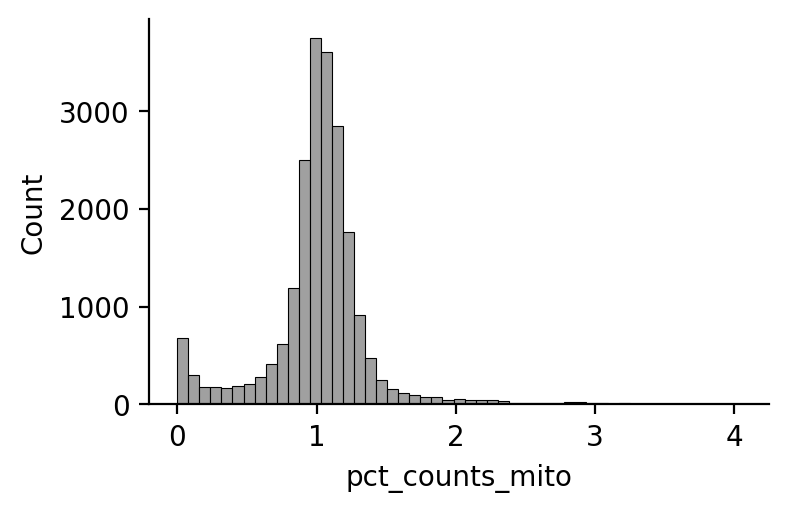

In [8]:
%%time
rsc.get.anndata_to_CPU(adata)

# Remove cells with high mitocondrial
adata.var["mito"] = adata.var_names.str.startswith("MT-")
adata.var["ribo"] = adata.var_names.str.startswith("RP")

sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=["mito", "ribo"],
    inplace=True,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 2.5

sns.histplot(
    adata.obs["pct_counts_mito"],
    bins=51,
    color='grey'
)

sns.despine()

In [9]:
threshold = 2.0
adata = adata[adata.obs['pct_counts_mito'] < threshold, :].copy()
adata

AnnData object with n_obs × n_vars = 21062 × 25739
    obs: 'dataset', 'source', 'cluster', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mito'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony', 'X_umap_bbknn', 'X_umap_harmony', 'X_umap_raw'
    varm: 'PCs'
    layers: 'log_norm', 'raw_counts'

# Gene Filtering

In [10]:
rsc.get.anndata_to_GPU(adata)

adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
True     14528
False    11211


# scvi

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA A100 80GB PCIe MIG 3g.40gb') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-bffcf947-2035-5281-9af9-cb80e2ba802c]


Training:   0%|          | 0/1000 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 10 records. Best score: 1573.117. Signaling Trainer to stop.


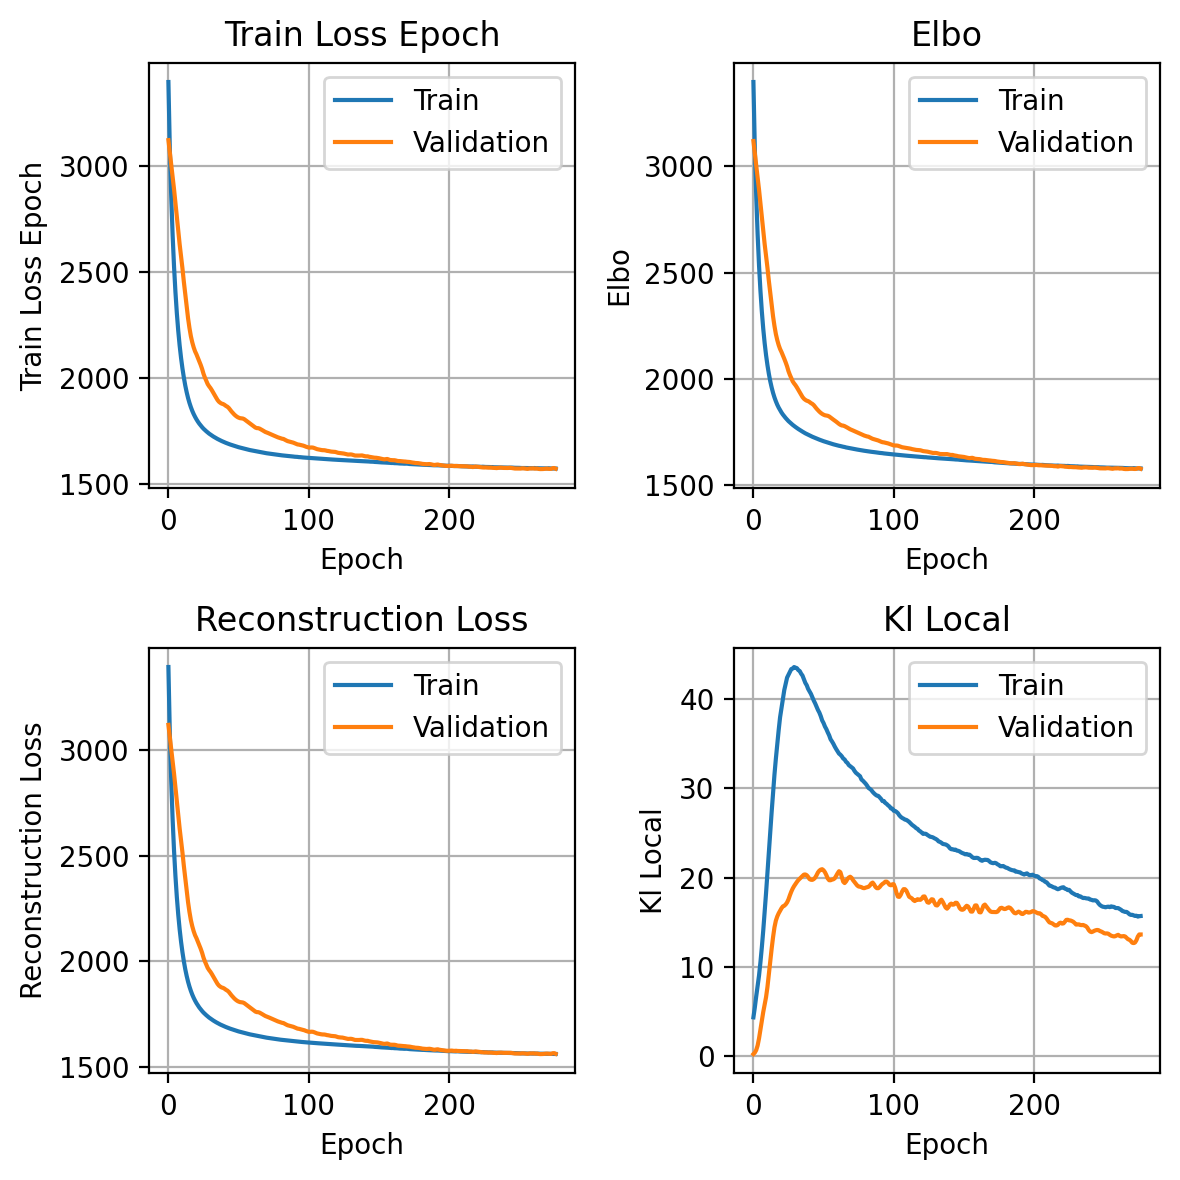

CPU times: user 56.7 s, sys: 55.5 s, total: 1min 52s
Wall time: 1min 52s


In [11]:
%%time
batch_key = "source"

bdata = adata.copy()
bdata = bdata[:, bdata.var['filter_pass']].copy()
bdata.X = bdata.layers['raw_counts'].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=2500,
    batch_key=batch_key,
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    batch_key=batch_key,
    continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=24,
    n_layers=2, 
    dropout_rate=0.25,
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=1000,
    accelerator='gpu',
    early_stopping_patience=10,
    early_stopping=True,
    batch_size=2 ** 14,
    train_size=0.8,
)

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# PAGA and UMAP 

[2025-06-25 11:39:05.498] [CUML] [info] Unused keyword parameter: random_state during cuML estimator initialization


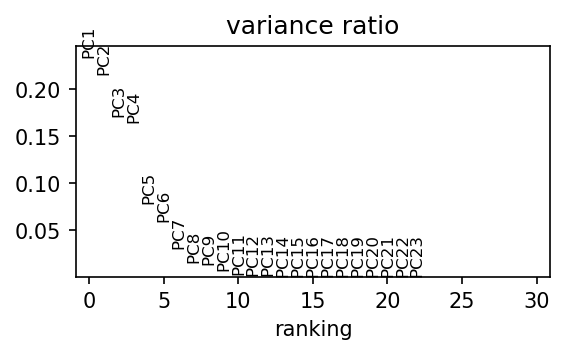

[2025-06-25 11:39:05.663] [CUML] [debug] Calling UMAP::get_graph() with precomputed KNN
[2025-06-25 11:39:05.663] [CUML] [debug] n_neighbors=35
[2025-06-25 11:39:05.663] [CUML] [debug] Calling knn graph run
[2025-06-25 11:39:05.663] [CUML] [debug] Done. Calling fuzzy simplicial set
[2025-06-25 11:39:05.669] [CUML] [debug] Done. Calling remove zeros
running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)
--> added 'pos', the PAGA positions (adata.uns['paga'])


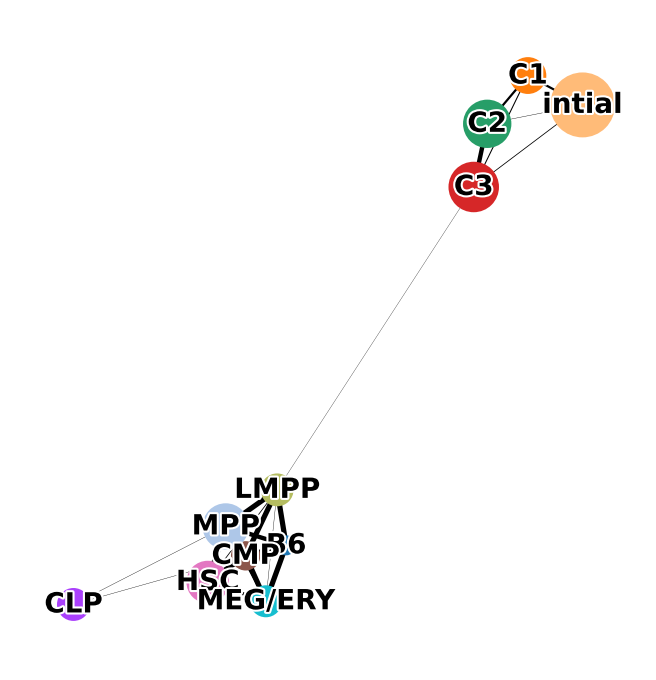

init_pos.shape=(21062, 2) type(init_pos)=<class 'numpy.ndarray'>
data.shape=(21062, 24) type(data)=<class 'cupy.ndarray'>
graph.shape=(21062, 21062) type(graph)=<class 'scipy.sparse._csr.csr_matrix'>
min_dist=0.2 spread=0.55 a=3.4688447773350513 b=1.182307511241454
[2025-06-25 11:39:06.819] [CUML] [debug] Calling UMAP::refine() with precomputed KNN
embedding.shape=(21062, 2) type(embedding)=<class 'cuml.internals.array.CumlArray'>


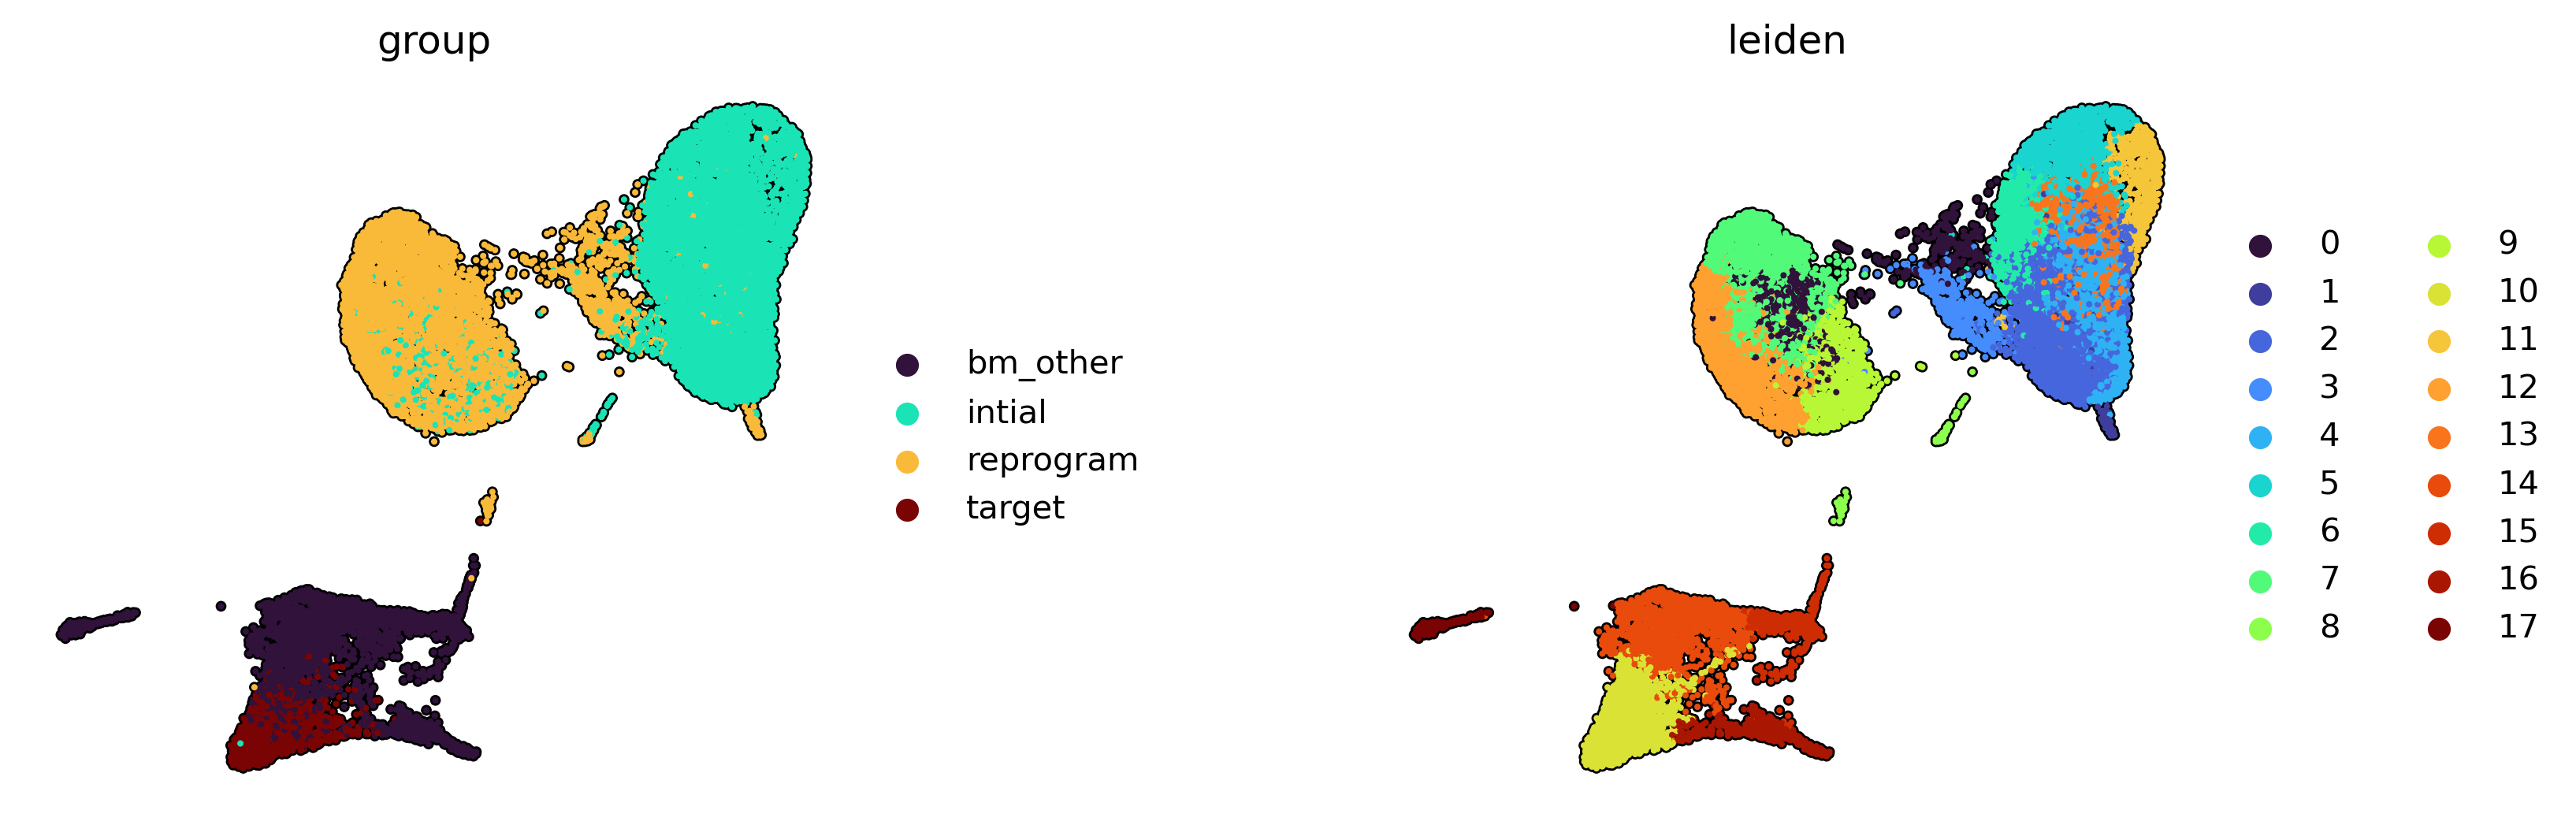

CPU times: user 3.23 s, sys: 232 ms, total: 3.46 s
Wall time: 3.47 s


In [52]:
%%time 

n_neighbors = 35
paga_group_column = "label"
n_pcs = 50
min_dist = 0.2
spread = 0.55
leiden_resolution = 0.65
colormap = 'turbo'

"""
PAGA
"""
embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)
rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

# plot the embedding
sc.tl.paga(embed, groups=paga_group_column)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4
sc.pl.paga(
    embed, 
    fontoutline=1.5, 
    edge_width_scale=0.25,  
    frameon=False,          
)

embed.obsm['X_paga'] = get_init_pos_from_paga(embed)

"""
UMAP
"""
# get the inputs
init_pos = embed.obsm['X_paga'].copy()
data = embed.X.copy()
graph = embed.obsp['connectivities'].copy()

print(f"{init_pos.shape=} {type(init_pos)=}")
print(f"{data.shape=} {type(data)=}")
print(f"{graph.shape=} {type(graph)=}")

# find params
a, b = find_ab_params(spread=spread, min_dist=min_dist)
print(f"{min_dist=} {spread=} {a=} {b=}")

# use simplicial_set_embedding
embedding = simplicial_set_embedding(
    data=data,
    graph=graph,
    a=a, b=b,
    n_components=2,
    init=init_pos,
    random_state=1729,
)

# store embedding
print(f"{embedding.shape=} {type(embedding)=}")
embed.obsm['X_umap'] = embedding.to_device_array().get().copy()

rsc.tl.leiden(embed, resolution=leiden_resolution)

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    embed, 
    color=['group', 'leiden'], 
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    palette=colormap,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

# cluster QC

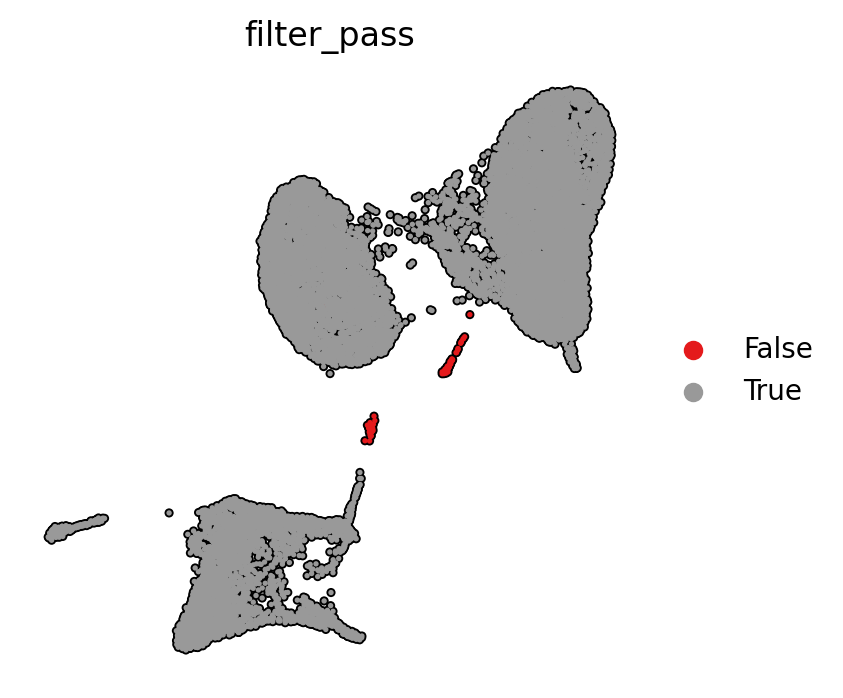

In [53]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

cluster_blacklist = ['8']

embed.obs['filter_pass'] = ~embed.obs['leiden'].isin(cluster_blacklist)

sc.pl.umap(
    embed, 
    color='filter_pass', 
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    palette='Set1',
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

# add embedding into Adata

filter_pass
True     20931
False      131

['MPP', 'MEG/ERY', 'CMP', 'HSC', 'LMPP', 'CLP', 'B6', 'C3', 'intial', 'C2', 'C1']


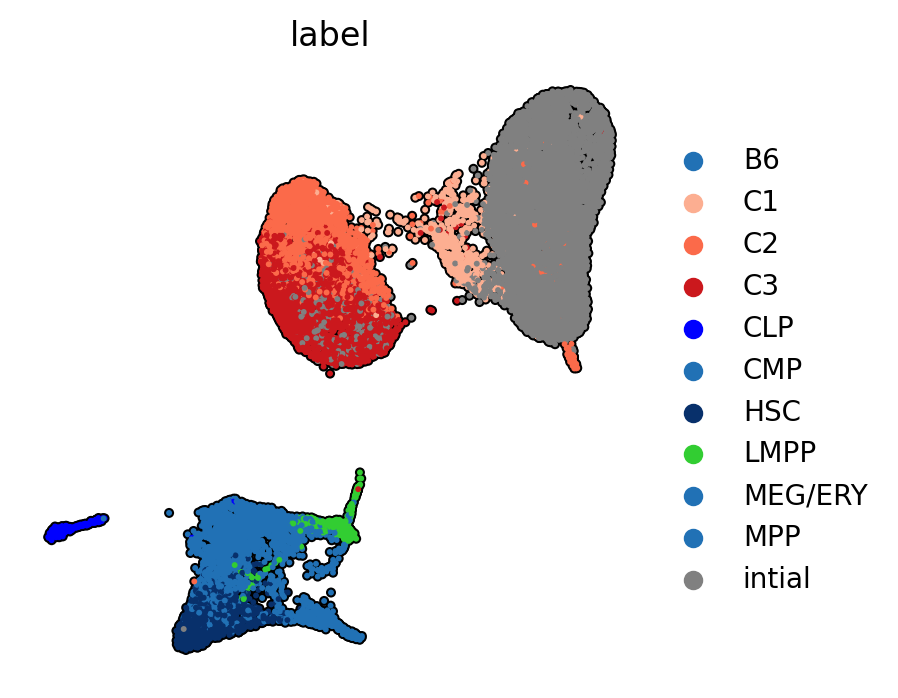

AnnData object with n_obs × n_vars = 21062 × 25739
    obs: 'dataset', 'source', 'cluster', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'filter_pass', 'bm_clusters'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mito', 'filter_pass'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony', 'X_umap_bbknn', 'X_umap_harmony', 'X_umap_raw', 'X_paga', 'X_scvi'
    varm: 'PCs'
    layers

In [54]:
adata.obsm['X_paga'] = embed.obsm['X_paga'].copy()
adata.obsm['X_umap'] = embed.obsm['X_umap'].copy()
adata.obsm['X_scvi'] = embed.X.copy()

# get filter column
adata.obs['bm_clusters'] = embed.obs['leiden'].apply(lambda x: f"M{int(x) + 1}")
adata.obs['filter_pass'] = embed.obs['filter_pass'].copy().astype(bool)

print(adata.obs['filter_pass'].value_counts().to_string())


print()
print(list(adata.obs['label'].unique()))

palette = {
    # HSC group – blues
    'HSC'     : '#08306B',
    'B6'      : '#2171B5',
    'MPP'     : '#2171B5',
    'MEG/ERY' : '#2171B5',
    'CMP'     : '#2171B5',
    'LMPP'    : 'limegreen',
    'CLP'     : 'b',

    # reprogram group – reds
    'C1'      : '#FCAE91',
    'C2'      : '#FB6A4A',
    'C3'      : '#CB181D',

    # initial group – neutral grey
    'intial'  : '#808080',
}


sc.pl.umap(
    adata[adata.obs['filter_pass']], 
    color='label', 
    size=18,
    ncols=3,
    alpha=1,
    use_raw=False,
    na_in_legend=False,
    palette=palette,
    add_outline=True,
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

adata

In [57]:
subgroup_label = {
    'HSC'     : 'HSC',
    'B6'      : 'progenitors',
    'MPP'     : 'progenitors',
    'MEG/ERY' : 'progenitors',
    'CMP'     : 'progenitors',
    'LMPP'    : 'LMPP',
    'CLP'     : 'CLP',
    'C1'      : 'C1',
    'C2'      : 'C2',
    'C3'      : 'C3',
    'intial'  : 'intial',
}

adata.obs['subgroup'] = adata.obs['label'].map(subgroup_label)
print(adata.obs['subgroup'].value_counts().to_string())

subgroup
intial         9039
C3             3140
progenitors    2956
C2             2611
HSC            1506
C1              814
CLP             500
LMPP            496


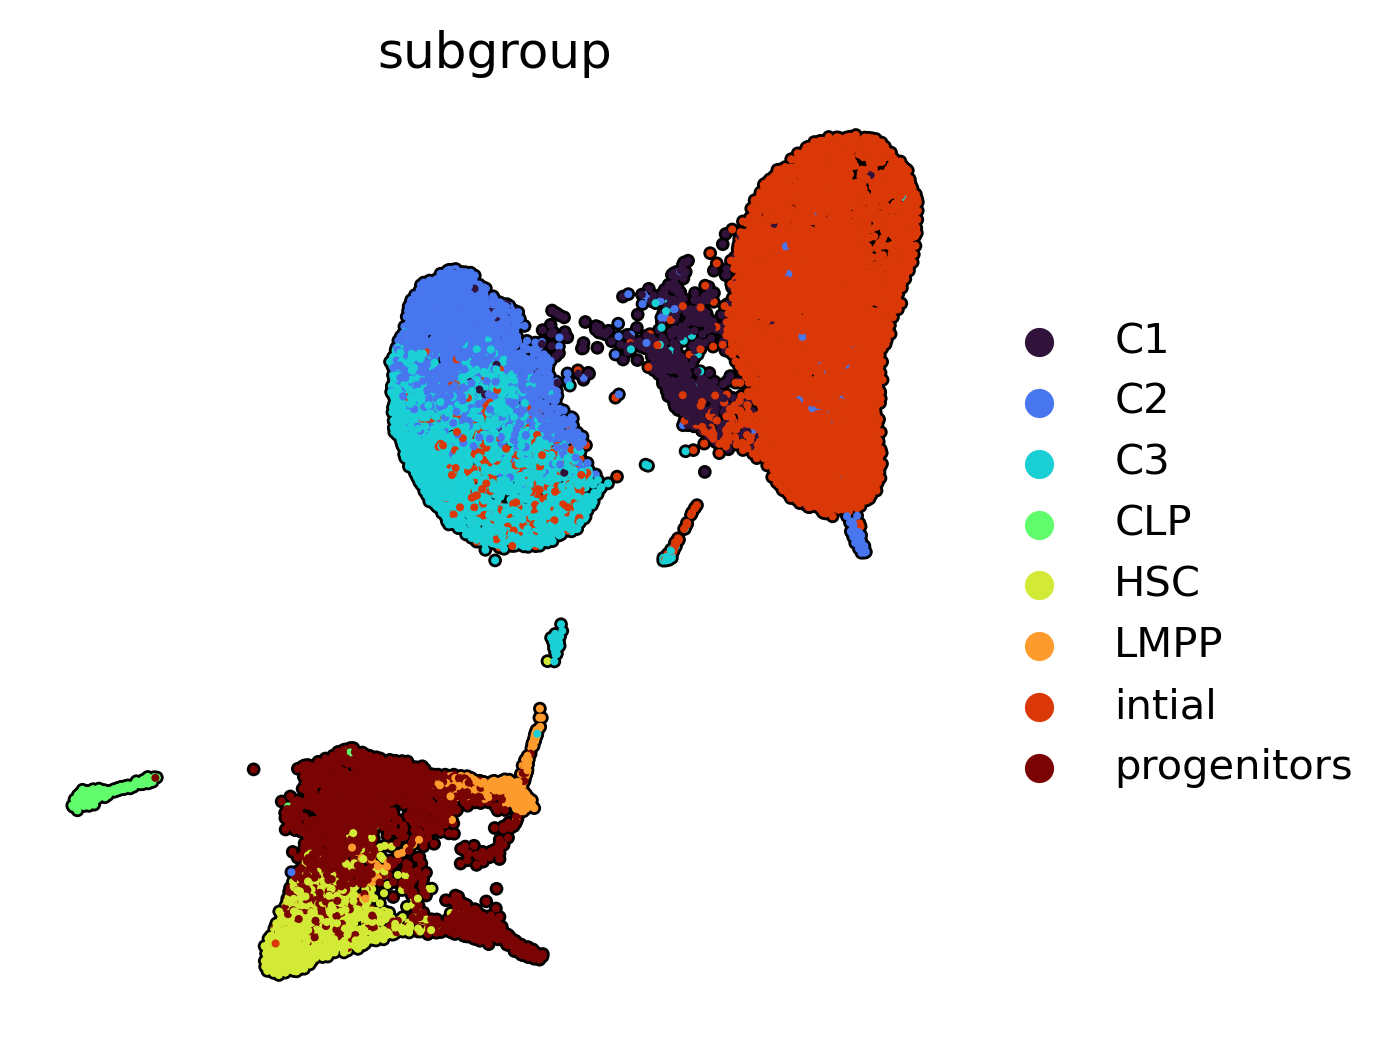

In [59]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata, 
    color='subgroup', 
    size=15,
    ncols=3,
    alpha=1,
    use_raw=False,
    add_outline=True,
    palette='turbo',
    outline_color=('k', 'k'),
    frameon=False,
    wspace=0.5,
)

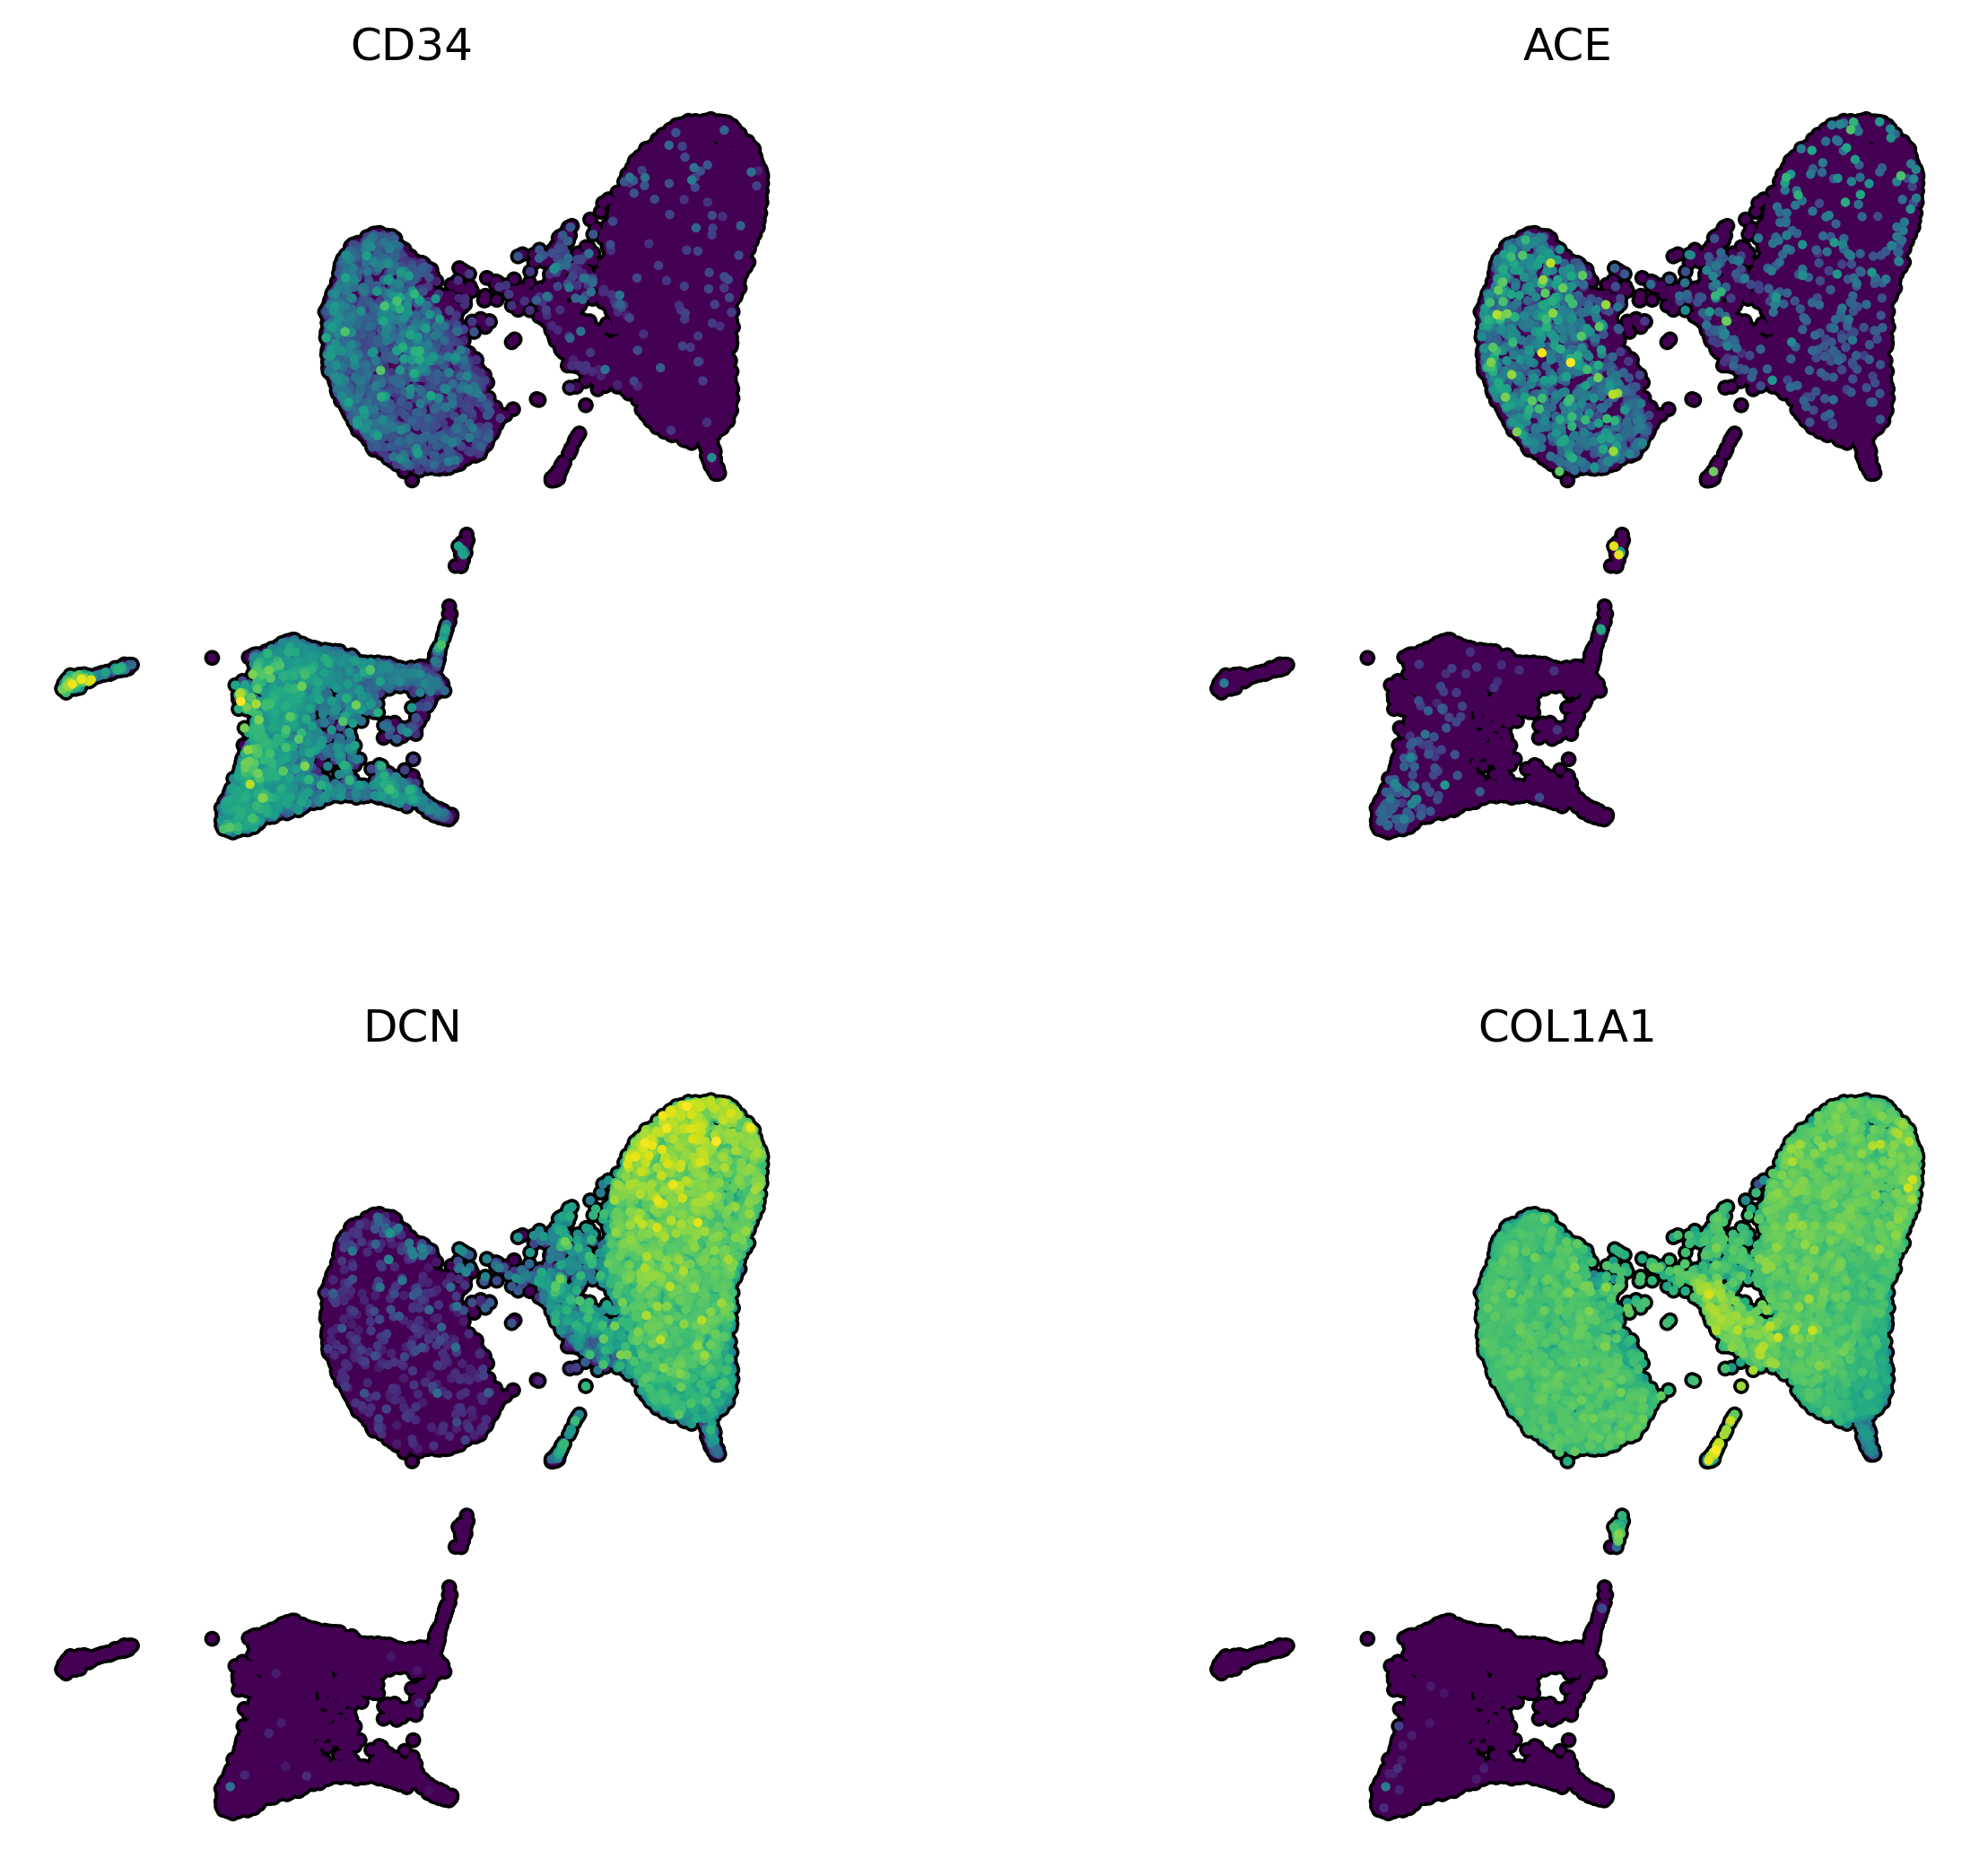

In [55]:
rsc.get.anndata_to_CPU(adata)

gene_list = [
    'CD34', 'ACE',
    'DCN', 'COL1A1', 
]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 3, 4

sc.pl.umap(
    adata, 
    color=gene_list,
    size=25,
    ncols=2,
    alpha=1,
    use_raw=False,
    add_outline=True,
    outline_color=('k', 'k'),
    colorbar_loc=None,
    frameon=False,
    wspace=0.5,
)

# Differential Expression

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:27)

filter_pass
False    260448
True      22681


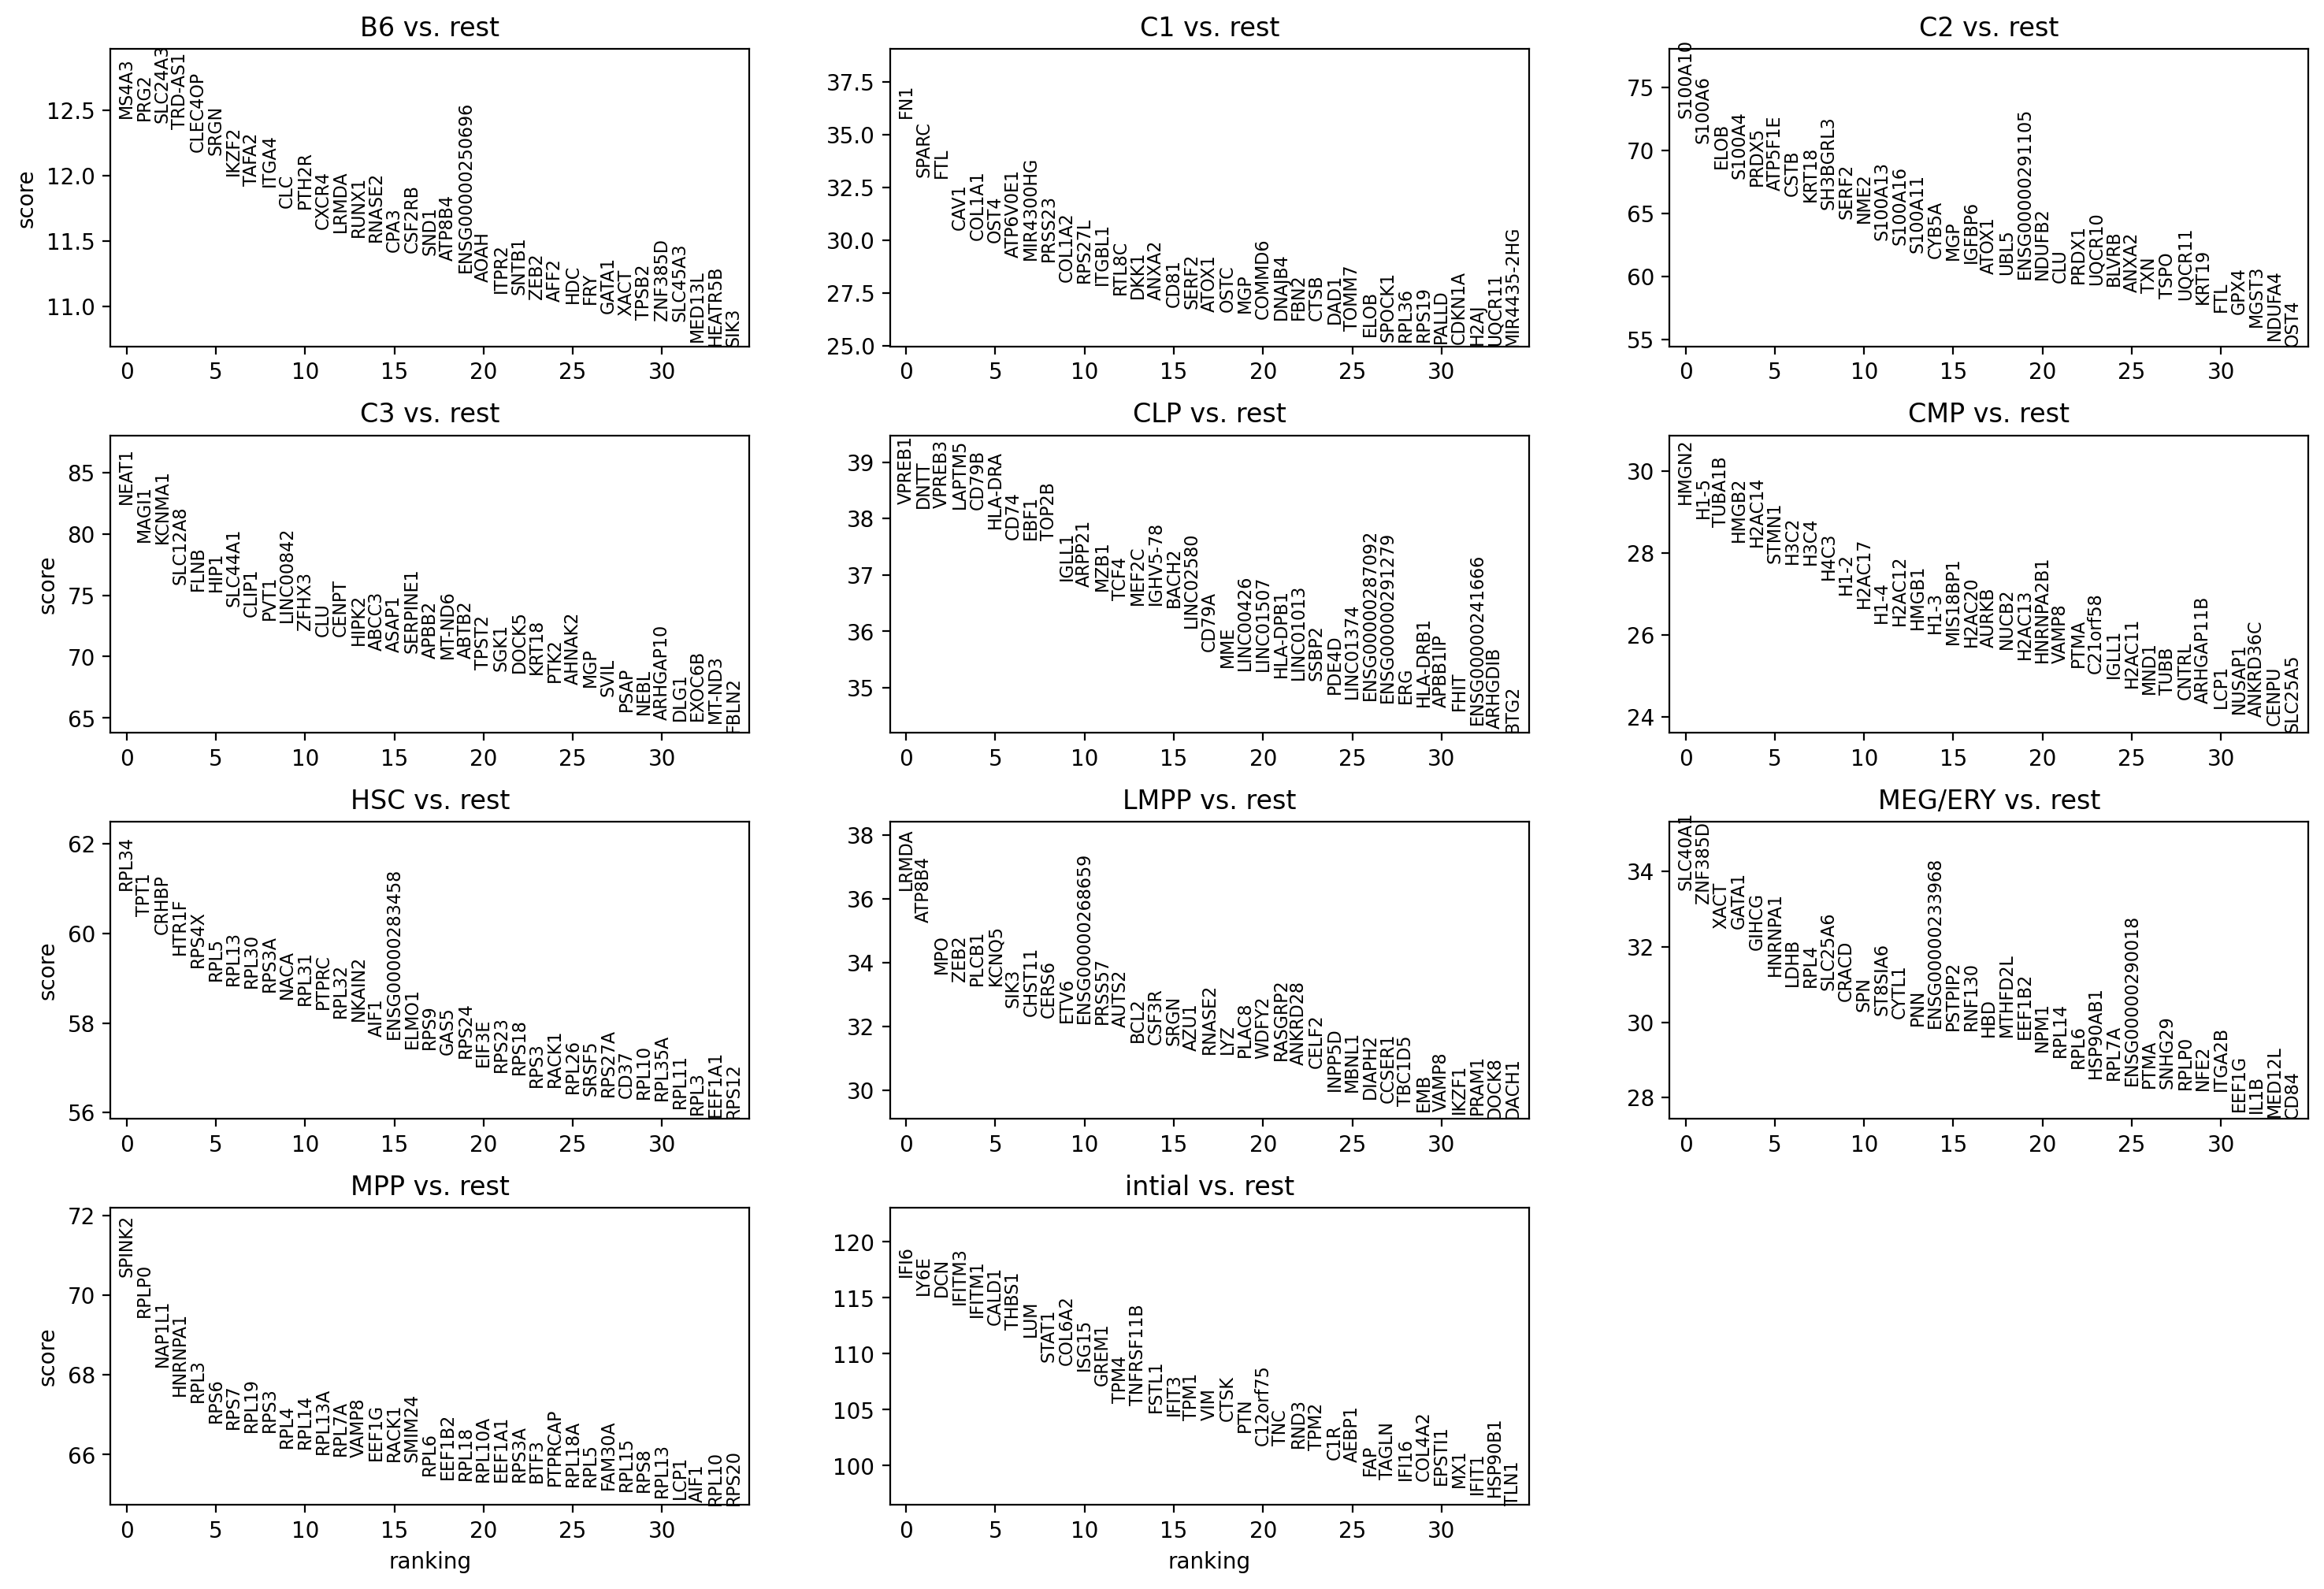

CPU times: user 47.2 s, sys: 31.1 s, total: 1min 18s
Wall time: 29.6 s


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,filter_pass
0,B6,MS4A3,12.441114,8.085391,1.563076e-35,2.153481e-31,1.000000,0.030271,True
1,B6,PRG2,12.419124,8.940626,2.058035e-35,2.153481e-31,1.000000,0.085578,True
2,B6,SLC24A3,12.403230,7.086060,2.509982e-35,2.153481e-31,1.000000,0.068396,True
3,B6,TRD-AS1,12.353288,6.537986,4.676043e-35,3.008917e-31,1.000000,0.052451,True
4,B6,CLEC4OP,12.180330,8.482717,3.956780e-34,2.036871e-30,0.980769,0.020562,True


In [107]:
%%time

sc.tl.rank_genes_groups(
    adata, 
    groupby='label',
    method='wilcoxon',
    layer='log_norm',
    use_raw=False,
    pts=True,
)

deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
)

# filter out some genes
deg['filter_pass'] = True
deg['filter_pass'] = np.where(deg['names'].str.startswith('RP'), False, deg['filter_pass'])
deg['filter_pass'] = np.where(deg['names'].str.startswith('MT'), False, deg['filter_pass'])
deg['filter_pass'] = np.where(deg['names'].str.startswith('ENSG'), False, deg['filter_pass'])
deg['filter_pass'] = np.where(deg['names'].str.startswith('LINC'), False, deg['filter_pass'])
deg['filter_pass'] = np.where(deg['logfoldchanges'] > 1.0, deg['filter_pass'], False )
deg['filter_pass'] = np.where(deg['pvals_adj'] < 0.05, deg['filter_pass'],  False)

print()
print(deg['filter_pass'].value_counts().to_string())

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    adata,
    n_genes=35,
    sharey=False,
    ncols=3,
)

deg.head()

In [108]:
print(deg.head().to_string(index=False))

group   names    scores  logfoldchanges        pvals    pvals_adj  pct_nz_group  pct_nz_reference  filter_pass
   B6   MS4A3 12.441114        8.085391 1.563076e-35 2.153481e-31      1.000000          0.030271         True
   B6    PRG2 12.419124        8.940626 2.058035e-35 2.153481e-31      1.000000          0.085578         True
   B6 SLC24A3 12.403230        7.086060 2.509982e-35 2.153481e-31      1.000000          0.068396         True
   B6 TRD-AS1 12.353288        6.537986 4.676043e-35 3.008917e-31      1.000000          0.052451         True
   B6 CLEC4OP 12.180330        8.482717 3.956780e-34 2.036871e-30      0.980769          0.020562         True


/tmp/ipykernel_1480718/319814636.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  top10 = filtered.groupby('group', group_keys=False).apply(


len(top10.names)=55
len(set(top10.names))=52


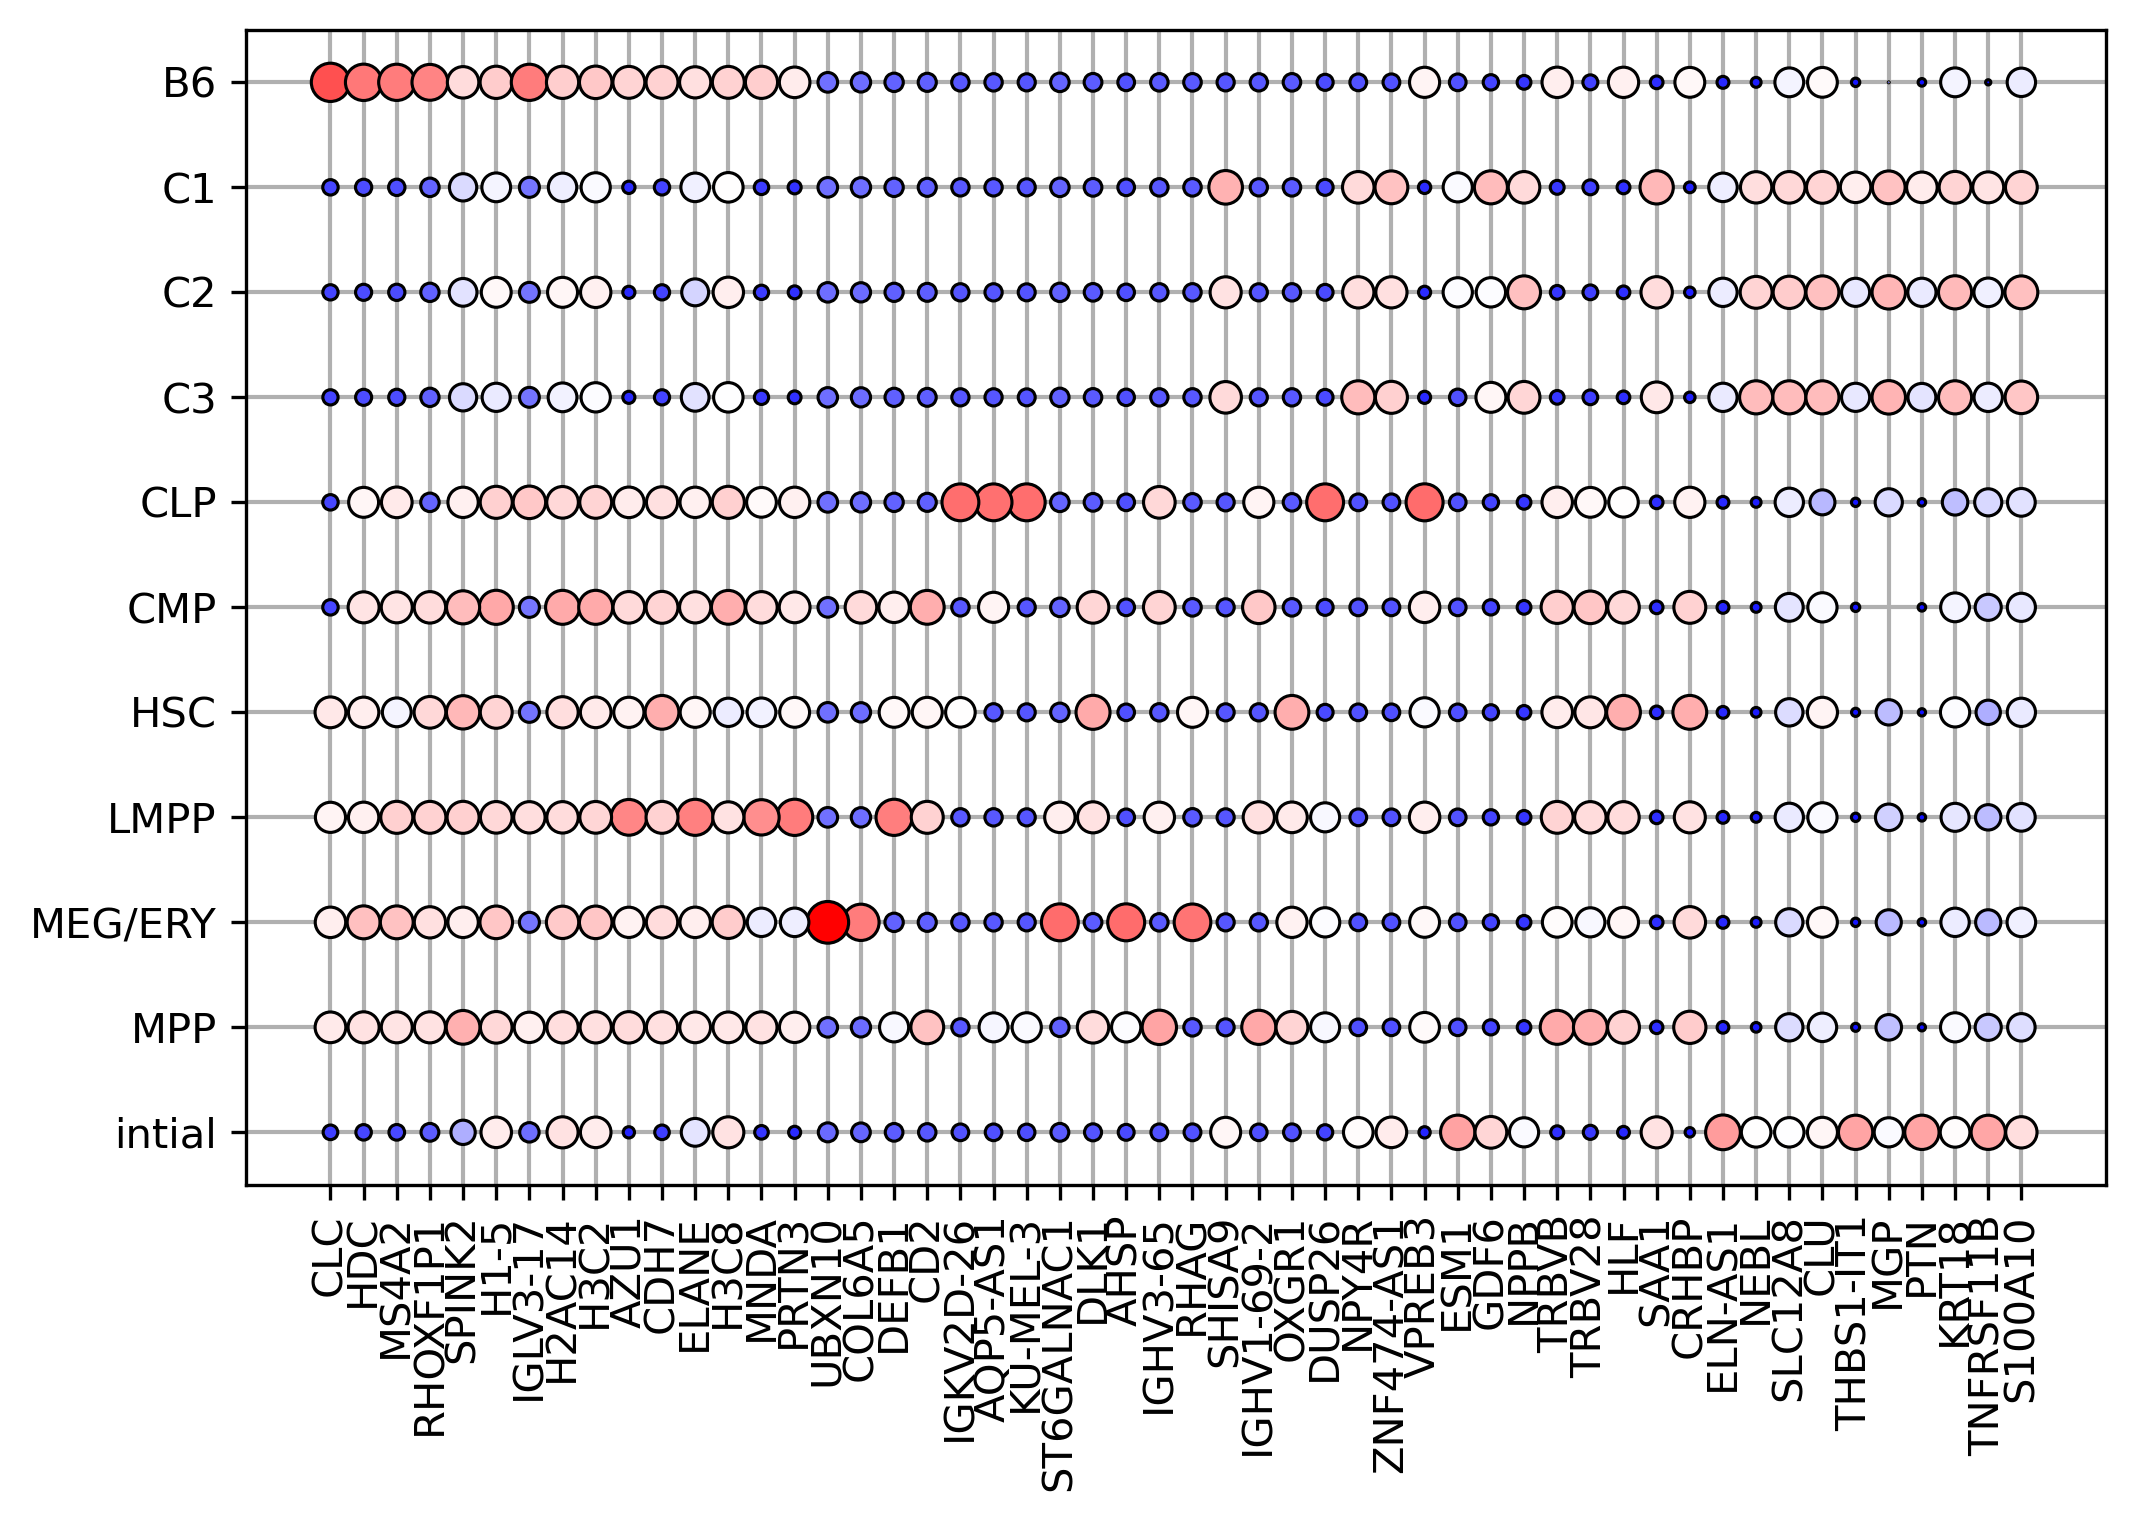

In [110]:
n_genes = 5
# Filter rows
filtered = deg[deg['filter_pass'] == True]

# Get top 10 by logfold change within each group
top10 = filtered.groupby('group', group_keys=False).apply(
    lambda g: g.nlargest(n_genes, 'logfoldchanges')
)

print(f"{len(top10.names)=}")
print(f"{len(set(top10.names))=}")

df = deg.copy()
df = df[df['names'].isin(top10.names)]

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 8, 5

sns.scatterplot(
    data=df, 
    x='names',
    y='group',
    size='logfoldchanges',
    hue='logfoldchanges',
    sizes=(0, 100),
    ec='k',
    lw=0.75,
    legend=False,
    palette='bwr',
    zorder=10,
)

plt.ylabel("")
plt.xlabel("")
plt.xticks(rotation=90)
plt.grid(True, lw=1, zorder=0)
plt.show()

# add normalized expression

In [116]:
adata.uns['scvi_expression'] = model.get_normalized_expression()
adata.uns['deg'] = deg.copy()
adata

AnnData object with n_obs × n_vars = 21062 × 25739
    obs: 'dataset', 'source', 'cluster', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mito', 'filter_pass'
    uns: 'subgroup_colors', 'rank_genes_groups', 'deg', 'scvi_expression'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony', 'X_umap

# Write out

In [126]:
%%time
outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/three_libraries.h5ad"

# move to CPU
rsc.get.anndata_to_CPU(adata, convert_all=True)

# fix data typing issues in var
adata.var['mt'] = adata.var['mt'].astype(bool)
adata.var['hb'] = adata.var['hb'].astype(bool)
adata.var['highly_variable'] = adata.var['highly_variable'].astype(bool)
adata.var['highly_variable_intersection'] = adata.var['highly_variable_intersection'].astype(bool)

adata.write(outpath)
adata

CPU times: user 2.92 s, sys: 2.35 s, total: 5.27 s
Wall time: 15.4 s


AnnData object with n_obs × n_vars = 21062 × 25739
    obs: 'dataset', 'source', 'cluster', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mito', 'filter_pass'
    uns: 'subgroup_colors', 'rank_genes_groups', 'deg', 'scvi_expression'
    obsm: 'X_pca', 'X_umap', 'X_pca_harmony', 'X_umap

In [128]:
adata.obs_names[:10]

Index(['AAACCAAAGGCGATCT-1-bone_marrow', 'AAACCAAAGGTGAACG-1-bone_marrow',
       'AAACCATTCCCTGTCA-1-bone_marrow', 'AAACCATTCCGCGATG-1-bone_marrow',
       'AAACCATTCCTGTCGC-1-bone_marrow', 'AAACCCGCAACTGGCA-1-bone_marrow',
       'AAACCCGCATAACTAG-1-bone_marrow', 'AAACCGCTCACTCTCG-1-bone_marrow',
       'AAACGAATCTCATCAC-1-bone_marrow', 'AAACGACAGCCATCAA-1-bone_marrow'],
      dtype='object')

In [ ]:
break